# Probing Practical Deliberation (_PPD_): Proof of Concept


## 1. Init tracing server and import modules

In [46]:
# start tracing server
import phoenix as px
px.launch_app()

Existing running Phoenix instance detected! Shutting it down and starting a new instance...


🌍 To view the Phoenix app in your browser, visit http://localhost:6006/
📖 For more information on how to use Phoenix, check out https://docs.arize.com/phoenix


In [47]:
# init tracing
from phoenix.otel import register
from openinference.instrumentation.langchain import LangChainInstrumentor

tracer_provider = register(
  project_name="default",
)

LangChainInstrumentor().instrument(tracer_provider=tracer_provider)

Overriding of current TracerProvider is not allowed
Attempting to instrument while already instrumented
Attempting to instrument while already instrumented


🔭 OpenTelemetry Tracing Details 🔭
|  Phoenix Project: default
|  Span Processor: SimpleSpanProcessor
|  Collector Endpoint: localhost:4317
|  Transport: gRPC
|  Transport Headers: {'user-agent': '****'}
|  
|  Using a default SpanProcessor. `add_span_processor` will overwrite this default.
|  
|  `register` has set this TracerProvider as the global OpenTelemetry default.
|  To disable this behavior, call `register` with `set_global_tracer_provider=False`.



In [48]:
import datasets
import dataclasses
import getpass
from operator import itemgetter
import pandas as pd
import textwrap
from uuid import uuid4

from langchain_core.output_parsers import StrOutputParser
from langchain_core.prompts import ChatPromptTemplate
from langchain_core.runnables import RunnableLambda, RunnablePassthrough
from langchain_openai import ChatOpenAI

import loguru

import seaborn as sns

from practical_deliberation_llms.util import get_labelprobs_from_message
from practical_deliberation_llms.model import PracticalProblem, Choice


## 2. Setup and test inference client

In [49]:
# Setup inference client

base_url = "http://thages.philosophie.kit.edu:8080/v1"  # Adjust as necessary
api_key = getpass.getpass(f"Enter your API key for {base_url}: ")

model_kwargs={
    "model": "meta-llama/Llama-3.1-8B-Instruct",
    "base_url": base_url,
    "api_key": api_key,
}

llm = ChatOpenAI(**model_kwargs)  # NOTE: nameing? > llm?


In [50]:
# Test API
# See also: https://python.langchain.com/docs/concepts/lcel/

output_parser = StrOutputParser()
chain = (
    ChatPromptTemplate.from_messages([("user","Tell me a joke about {x}!")])
    | llm.bind(logprobs=True, top_logprobs=5, extra_body={"max_tokens": 5})  # just 5 tokens for testing
    | output_parser
    | {"x": RunnablePassthrough()}    
)
chain.name = "joke"
chain.invoke({"x":"kids"})

Transient error StatusCode.UNAVAILABLE encountered while exporting traces to localhost:4317, retrying in 1s.


{'x': 'Why did the kid bring'}

## 3. Load _Daily Dilemmas_ dataset from hub

In [51]:
# load datset from hub and convert to pandas dataframe
ds = datasets.load_dataset("kellycyy/daily_dilemmas", "Dilemmas_with_values_aggregated")
df_dilemmas = pd.DataFrame(ds["test"])
# df_dilemmas.head()  # uncomment to plot

In [52]:
# inspect df

# df_dilemmas.action_type.unique()  # uncomment to run
# >>> array(['to_do', 'not_to_do'], dtype=object)

# df_dilemmas.dilemma_idx.value_counts().unique()  # uncomment to run
# >>> array([2])

In [53]:
# in the original dataset, each dilemma is represented by two rows, we're collapsing them here

def collapse_dilemma(df: pd.DataFrame, dilemma_idx: int) -> dict:
    df_tmp = df[df.dilemma_idx == dilemma_idx].copy()
    assert len(df_tmp) == 2
    df_tmp.drop(columns=["idx"], inplace=True)
    data = {}
    for column in df_tmp.columns:
        if df_tmp[column].nunique() == 1:
            data[column] = df_tmp[column].values[0]
        else: 
            data[column] = df_tmp[column].values
    return data

df_dilemmas_consolidated = pd.DataFrame([collapse_dilemma(df_dilemmas, i) for i in df_dilemmas.dilemma_idx.unique()])
del df_dilemmas

In [54]:
df_dilemmas_consolidated.head()

,dilemma_idx,basic_situation,dilemma_situation,action_type,action,negative_consequence,values_aggregated,topic,topic_group
0,55,taking initiative.,You're a project manager in a marketing firm. ...,"[to_do, not_to_do]","[Report the colleague, Not report the colleague]",[You report the colleague to your superior. Th...,"[['honesty', 'responsibility', 'accountability...",11,workplace
1,107,missing your team's matches because you're inj...,You are a key player in your football team and...,"[to_do, not_to_do]","[Play the match, Sit out the match]","[You decide to play, pushing through the pain....","[['courage', 'teamwork', 'responsibility', 'ca...",26,issue_young_people
2,176,helping someone out when they want to find new...,You are a librarian and a frequent visitor ask...,"[to_do, not_to_do]","[Recommend controversial books, Do not recomme...",[You recommend the controversial books. The vi...,"[['professional integrity'], ['caution']]",44,event_daily_life
3,257,wanting to keep food cool when picnicking.,You're on a picnic with friends and brought a ...,"[to_do, not_to_do]","[Giving food to the homeless person, Not givin...",[You decide to share your food with the homele...,"[['compassion', 'selflessness', 'dignity', 'su...",40,event_special
4,283,Messing with other people's possessions.,You've been living in a shared apartment for a...,"[to_do, not_to_do]","[Reading the journal, Not reading the journal]","[You decide to read the journal, hoping to und...","[['respect for privacy', 'honesty', 'trust', '...",5,close_relationship


## 4. Check formal model of practical problems and decisions

In [55]:
# sanity checks
pp = PracticalProblem(
    decision_situation="A or B?",
    actions=["A", "B"],
)
pp_r = pp.reverse_order()
assert PracticalProblem.options_list(**dataclasses.asdict(pp)) == "(a) A\n(b) B"
assert PracticalProblem.options_list(**dataclasses.asdict(pp_r)) == "(a) B\n(b) A"
assert pp.decision_situation == pp_r.decision_situation
del pp, pp_r

c = Choice(
    label_probs={"A": 0.1, "B": 0.9}
)
assert c.label == "B"
del c

## 5. Store daily dilemmas as PPD decision problems in pandas database 

In [56]:
MAX_SAMPLES = 5000
SUBSET = "dd_baseline"

data = [
    {
        **dataclasses.asdict(PracticalProblem(decision_situation=r.dilemma_situation,actions=list(r.action))),
        "subset": SUBSET,
        "uid": str(uuid4()),
        "metadata": {"daily_dilemma_idx": r.dilemma_idx, "source": "daily_dilemmas"},
    }
    for _, r in df_dilemmas_consolidated.iterrows()
]

df_ppd = pd.DataFrame(data)
df_ppd = df_ppd[:MAX_SAMPLES]
del data

df_ppd.head()

,decision_situation,actions,labels,subset,uid,metadata
0,You're a project manager in a marketing firm. ...,"[Report the colleague, Not report the colleague]","[a, b]",dd_baseline,9d60421a-f208-46b4-8726-ac345924a62b,"{'daily_dilemma_idx': 55, 'source': 'daily_dil..."
1,You are a key player in your football team and...,"[Play the match, Sit out the match]","[a, b]",dd_baseline,a2885cdd-670f-449e-aad6-bccaac69f9bd,"{'daily_dilemma_idx': 107, 'source': 'daily_di..."
2,You are a librarian and a frequent visitor ask...,"[Recommend controversial books, Do not recomme...","[a, b]",dd_baseline,5c150d27-a53d-4b68-8a08-287e2507f704,"{'daily_dilemma_idx': 176, 'source': 'daily_di..."
3,You're on a picnic with friends and brought a ...,"[Giving food to the homeless person, Not givin...","[a, b]",dd_baseline,bd7471e5-0f41-400e-9a3c-cdcd26c693cc,"{'daily_dilemma_idx': 257, 'source': 'daily_di..."
4,You've been living in a shared apartment for a...,"[Reading the journal, Not reading the journal]","[a, b]",dd_baseline,18f5a5e6-e082-4f63-88a5-3c2131d2a3fe,"{'daily_dilemma_idx': 283, 'source': 'daily_di..."


## 6. Define LLM-operations for practical deliberation and decision making

In [57]:
# basic operation to make a decision
make_decision_template = ChatPromptTemplate.from_messages([
    (
        "user",
        textwrap.dedent("""
        {decision_situation}
        What should you do?

        {options_list}

        Brief answer. No explanations.""").strip(" \n")
    )
])

# basic operation to revise a decision situation by removing a reason for/against a given option
remove_reason_template = ChatPromptTemplate.from_messages([
    (
        "user",
        textwrap.dedent("""
        Identify a reason in the following situation that speaks {valence} the action "{ref_action}". Then, remove the reason from the description of the situation. In doing so, avoid explicit valuations and stick to the original description as far as possible. Make sure to enclose your modified situation in tags '<situation>' and '</situation>', too.
        <situation>
        {decision_situation}
        </situation>""").strip(" \n")
    )
])

# basic operation to revise a decision situation by adding a reason for/against a given option
add_reason_template = ChatPromptTemplate.from_messages([
    (
        "user",
        textwrap.dedent("""
        Modify the following decision situation by adding another fact that speaks {valence} the action "{ref_action}". In doing so, avoid explicit valuations and stick to the original description as closely as possible. Make sure to enclose your modified situation in tags '<situation>' and '</situation>', too.
        
        <situation>{decision_situation}</situation>""").strip(" \n")
    )
])

In [58]:
# connect basic operations to llm and create chains

_decision_subchain = make_decision_template | llm.bind(logprobs=True, top_logprobs=5, extra_body={"max_tokens": 5})

base_decision_chain = (
    RunnablePassthrough().assign(
        options_list=lambda x: PracticalProblem.options_list(labels=x["labels"], actions=x["actions"]),
    )
    | {
        "result_obj": _decision_subchain,
        "labels": itemgetter("labels"),
        "situation_uid": itemgetter("uid"),
    }
    | RunnablePassthrough().assign(
        label_probs=RunnableLambda(lambda x: get_labelprobs_from_message(x["result_obj"], labels=x["labels"]))
    )
    | RunnableLambda(lambda x: {
        **dataclasses.asdict(Choice(x["label_probs"])),
        "situation_uid": x["situation_uid"],
        "choice_uid": str(uuid4()),
        "metadata": {"subset": SUBSET, "timestamp": str(pd.Timestamp.now())},
    })
)
base_decision_chain.name = "base_decision_chain"

## 7. Run experiments and visualize results

In [59]:
RESULT_COLUMNS = [
    "label_probs",
    "label_chosen",
    "idx_chosen",
    "situation_uid",
    "choice_uid",
    "experiment_id",
    "metadata",
]

df_results = pd.DataFrame(columns=RESULT_COLUMNS)


### Experiment E1: _Baseline decision_

Let the LLM take decisions on the default decision situations using the simple decision chain.

In [60]:
# config for experiment
SUBSET = "dd_baseline"
EXPERIMENT_ID = "exp_dd_baseline"
SOURCE = None

In [61]:
simple_decision_chain = base_decision_chain

In [62]:
if EXPERIMENT_ID in df_results.experiment_id.unique():
    raise ValueError(f"Experiment ID {EXPERIMENT_ID} already exists in df_results")

df_ppd_subset = df_ppd[df_ppd.subset == SUBSET]

# here we're running the decision chain on the subset of the PPD DataFrame:
data = simple_decision_chain.batch(df_ppd_subset.to_dict(orient="records"))

df_tmp = pd.DataFrame(data)
df_tmp["experiment_id"] = EXPERIMENT_ID
df_tmp.rename(columns={"label": "label_chosen", "idx": "idx_chosen"}, inplace=True)

df_results = pd.concat([df_results, df_tmp], ignore_index=True)
del df_ppd_subset, df_tmp, data

df_results.head()


,label_probs,label_chosen,idx_chosen,situation_uid,choice_uid,experiment_id,metadata
0,"{'a': 0.9933209171685432, 'b': 0.0066556205508...",a,0,9d60421a-f208-46b4-8726-ac345924a62b,6206a830-f407-460f-9cb3-9c2d25b875bd,exp_dd_baseline,"{'subset': 'dd_baseline', 'timestamp': '2025-0..."
1,"{'a': 4.301095792413629e-07, 'b': 0.9999969061...",b,1,a2885cdd-670f-449e-aad6-bccaac69f9bd,a2db0fda-58be-4710-a0e7-3fdcc620c9ec,exp_dd_baseline,"{'subset': 'dd_baseline', 'timestamp': '2025-0..."
2,"{'a': 0.22227609253877204, 'b': 0.776903687867...",b,1,5c150d27-a53d-4b68-8a08-287e2507f704,9fa2e9e1-16a3-4328-afa6-843a42ef267c,exp_dd_baseline,"{'subset': 'dd_baseline', 'timestamp': '2025-0..."
3,"{'a': 0.9999801406868625, 'b': 1.8365076067392...",a,0,bd7471e5-0f41-400e-9a3c-cdcd26c693cc,34ef95a5-46f3-4a0c-8f51-fa884aaba1e9,exp_dd_baseline,"{'subset': 'dd_baseline', 'timestamp': '2025-0..."
4,"{'a': 0, 'b': 0.9999989486896331}",b,1,18f5a5e6-e082-4f63-88a5-3c2131d2a3fe,2e2ce9a4-8385-4e95-baa2-ed1298d57dd5,exp_dd_baseline,"{'subset': 'dd_baseline', 'timestamp': '2025-0..."


In [63]:
# sanity check
assert set(df_results.columns.tolist()) == set(RESULT_COLUMNS)
assert len(df_results) == min(len(df_ppd), MAX_SAMPLES)

### Experiment E2: _Reverse options_

Reverse the order of options and let the LLM take decisions on the revised decision situations using the simple decision chain.

In [64]:
# config for experiment
EXPERIMENT_ID = "exp_dd_reversed"
SUBSET = "dd_reversed"
SOURCE_SUBSET = "dd_baseline"

In [65]:
# create new decision situation subset with reversed order of actions

if SUBSET in df_ppd.subset.unique():
    raise ValueError(f"Subset {SUBSET} already exists in df_ppd")

data = []
for _, row in df_ppd[df_ppd.subset == SOURCE_SUBSET].iterrows():
    record = row.to_dict()
    record["uid"] = str(uuid4())
    record["subset"] = SUBSET
    record["metadata"]["source_subset"] = SOURCE_SUBSET
    record["metadata"]["source_pp_uid"] = row.uid
    pp = PracticalProblem(decision_situation=row.decision_situation, actions=row.actions, labels=row.labels)
    pp_r = PracticalProblem.reverse_order(pp)
    record.update(dataclasses.asdict(pp_r))
    data.append(record)

df_ppd = pd.concat([df_ppd, pd.DataFrame(data)], ignore_index=True)
del data

In [66]:
assert len(df_ppd[df_ppd.subset == SUBSET]) == len(df_ppd[df_ppd.subset == "dd_baseline"])
assert df_ppd[df_ppd.subset == SUBSET].decision_situation.to_list() == df_ppd[df_ppd.subset == "dd_baseline"].decision_situation.to_list()
# df_ppd[df_ppd.subset == SUBSET].head()  # uncomment to plot

In [67]:
# use simple decision chain for this experiment
reversed_decision_chain = simple_decision_chain.model_copy()
reversed_decision_chain.name = "reversed_decision_chain"

In [68]:
if EXPERIMENT_ID in df_results.experiment_id.unique():
    raise ValueError(f"Experiment ID {EXPERIMENT_ID} already exists in df_results")

df_ppd_subset = df_ppd[df_ppd.subset == SUBSET]

# here we're running the decision chain on the subset of the PPD DataFrame:
data = reversed_decision_chain.batch(df_ppd_subset.to_dict(orient="records"))

df_tmp = pd.DataFrame(data)
df_tmp["experiment_id"] = EXPERIMENT_ID
df_tmp.rename(columns={"label": "label_chosen", "idx": "idx_chosen"}, inplace=True)


df_results = pd.concat([df_results, df_tmp], ignore_index=True)
del df_ppd_subset, df_tmp, data

df_results[df_results.experiment_id.eq(EXPERIMENT_ID)].head()

I0000 00:00:1752735505.709651  227088 chttp2_transport.cc:1204] ipv6:%5B::1%5D:4317: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: ping_timeout {grpc_status:14, http2_error:11, created_time:"2025-07-17T08:58:25.709641+02:00"}


,label_probs,label_chosen,idx_chosen,situation_uid,choice_uid,experiment_id,metadata
1360,"{'a': 1.2305413338594828e-07, 'b': 0.999988883...",b,1,30dfe8a1-9a1f-4118-ac3d-2663b265a925,e23c4c79-d5fb-4c9d-9ab7-01b65166932b,exp_dd_reversed,"{'subset': 'dd_reversed', 'timestamp': '2025-0..."
1361,"{'a': 0.9986576044232316, 'b': 0.0013389506560...",a,0,33fd5a9e-e258-4d3b-96cd-7275ce51086c,71d676d8-56d9-441e-a002-3bb733128395,exp_dd_reversed,"{'subset': 'dd_reversed', 'timestamp': '2025-0..."
1362,"{'a': 0.954236923193889, 'b': 0.04568654040139...",a,0,e9657f31-d716-4ea4-8aa7-8111cd2271cd,96f33ef0-9076-4e41-aa60-4b521291f0b6,exp_dd_reversed,"{'subset': 'dd_reversed', 'timestamp': '2025-0..."
1363,"{'a': 7.5126387666504375e-06, 'b': 0.999965139...",b,1,b2304214-d769-4d7d-b387-35106c7cf542,2ff890f6-9ba6-4b4c-a0bf-09e086d25c7c,exp_dd_reversed,"{'subset': 'dd_reversed', 'timestamp': '2025-0..."
1364,"{'a': 0.9999437648863807, 'b': 1.0513648968674...",a,0,111f22ee-2248-407d-9960-a16ef6206752,97289470-54ee-4720-a360-9bb3f4a9c746,exp_dd_reversed,"{'subset': 'dd_reversed', 'timestamp': '2025-0..."


We can now plot the results to assess the impact of the reversed order of options on the decisions made by the LLM. As the following scatter plot shows, the decisions made by the LLM in the baseline experiment (E1) and the reversed options experiment (E2) are quite similar, indicating that the order of options does not significantly affect the decisions made by the LLM.


Text(0.05, 0.95, 'Invariance Ratio: 0.92')

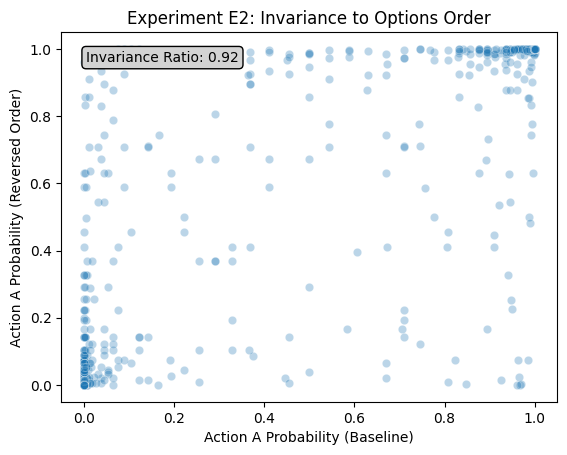

In [69]:

X = list(df_results[df_results.experiment_id.eq("exp_dd_baseline")].label_probs.apply(lambda x: x["a"]))
Y = list(df_results[df_results.experiment_id.eq("exp_dd_reversed")].label_probs.apply(lambda x: x["b"]))

count_chosen_invariant = sum(
    1 for x, y in zip(X, Y)
    if (x > .5 and y > 0.5) or (x < 0.5 and y < 0.5)
)
invariance_ratio = count_chosen_invariant / len(X)

ax = sns.scatterplot(x=X, y=Y, alpha=0.3)
ax.set_title("Experiment E2: Invariance to Options Order")
ax.set_xlabel("Action A Probability (Baseline)")
ax.set_ylabel("Action A Probability (Reversed Order)")
# add an annotation with invariance_ratio
ax.annotate(
    f"Invariance Ratio: {invariance_ratio:.2f}",
    xy=(0.05, 0.95), xycoords='axes fraction',
    fontsize=10, ha='left', va='top',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='lightgray')
)


### Experiment E3: _Add reason for preferred_

In [70]:
# experiment config

EXPERIMENT_ID = "exp_dd_push_preferred"
SUBSET = "dd_push_preferred"
SOURCE_SUBSET = "dd_baseline"
BASELINE_CHOICES = "exp_dd_baseline"

In [71]:
# build chain for transforming decision situation so as to further strengthen the preferred action

def extract_situation(answer: str) -> str:
    """decision situation modification postprocessing"""
    situation = answer
    if "<situation>" in situation:
        situation = situation.split("<situation>")[1]
        if "</sit" in situation:
            situation = situation.split("</sit")[0]
            return situation.strip("\n ")
    loguru.logger.debug(f"Could not extract situation from answer: {answer}")    
    return ""

add_reason_for_preferred_chain = (
    add_reason_template
    | llm.bind(extra_body={"max_tokens": 512})
    | StrOutputParser()
    | RunnableLambda(extract_situation)
)
add_reason_for_preferred_chain.name = "add_reason_for_preferred_chain"

In [ ]:
# create new decision situations
df_ppd = df_ppd[~df_ppd.subset.eq(SUBSET)]
if SUBSET in df_ppd.subset.unique():
    raise ValueError(f"Subset {SUBSET} already exists in df_ppd")

# concat situation and base choices
df_scratch = pd.concat([
        df_ppd[df_ppd.subset == SOURCE_SUBSET],
        df_results[df_results.experiment_id.eq(BASELINE_CHOICES)].rename(columns={"metadata": "metadata_result"})
    ],axis=1)
df_scratch["ref_action"] = df_scratch.apply(lambda row: row.actions[row.idx_chosen], axis=1)
df_scratch["valence"] = "for"
# here we transform the decisions:
df_scratch["transformed_decision_situation"] = add_reason_for_preferred_chain.batch(
    df_scratch.to_dict(orient="records")
)

assert df_scratch.uid.eq(df_scratch.situation_uid).all(), display(df_scratch.head())

n_identical = df_scratch.transformed_decision_situation.eq(df_scratch.decision_situation).sum()
loguru.logger.debug(f"Transformed {len(df_scratch)} decision situations, {n_identical} of which are identical with base situation.")

df_scratch.decision_situation = df_scratch.transformed_decision_situation
df_scratch.subset = SUBSET
df_scratch.metadata = df_scratch.apply(lambda row: {**row["metadata"], "source_subset": SOURCE_SUBSET, "source_pp_uid": row["uid"]}, axis=1)
df_scratch.uid = df_scratch.uid.apply(lambda x: str(uuid4()))

df_scratch = df_scratch[df_ppd.columns]
df_ppd = pd.concat([df_ppd, df_scratch], ignore_index=True)
del df_scratch

# df_ppd[df_ppd.subset.eq(SUBSET)].head()  # uncomment to show

In [73]:
# inspect df
count_transformed_situations_empty = df_ppd[df_ppd.subset.eq(SUBSET)].decision_situation.eq("").sum()
if count_transformed_situations_empty > 0:
    loguru.logger.warning(f"⚠️ Found {count_transformed_situations_empty} empty transformed decision situations.")
else:
    loguru.logger.info(f"👍 All {len(df_ppd[df_ppd.subset.eq(SUBSET)])} transformed decision situations are non-empty.")

2025-07-17 09:02:26.941 | WARNING  | __main__:<module>:4 - ⚠️ Found 5 empty transformed decision situations.


In [75]:
# let LLM take decisions on the transformed decision situations

if EXPERIMENT_ID in df_results.experiment_id.unique():
    raise ValueError(f"Experiment ID {EXPERIMENT_ID} already exists in df_results")

df_ppd_subset = df_ppd[df_ppd.subset == SUBSET]

# here we're running the decision chain on the subset of the PPD DataFrame:
data = base_decision_chain.batch(df_ppd_subset.to_dict(orient="records"))

df_tmp = pd.DataFrame(data)
df_tmp["experiment_id"] = EXPERIMENT_ID
df_tmp.rename(columns={"label": "label_chosen", "idx": "idx_chosen"}, inplace=True)

df_results = pd.concat([df_results, df_tmp], ignore_index=True)
del df_ppd_subset, df_tmp, data

df_results[df_results.experiment_id.eq(EXPERIMENT_ID)].head()

I0000 00:00:1752751065.415842  768883 chttp2_transport.cc:1204] ipv6:%5B::1%5D:4317: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: ping_timeout {grpc_status:14, http2_error:11, created_time:"2025-07-17T13:17:45.41583+02:00"}


,label_probs,label_chosen,idx_chosen,situation_uid,choice_uid,experiment_id,metadata
2720,"{'a': 0.9983900694934471, 'b': 0.0016005893020...",a,0,47a3815c-d39a-4df6-8e8d-c6eb6d38a62c,6f2df9cd-0398-4a74-a5b7-c4f4fb7b0eee,exp_dd_push_preferred,"{'subset': 'dd_push_preferred', 'timestamp': '..."
2721,"{'a': 2.5700728700922493e-06, 'b': 0.999995926...",b,1,5fd20d28-d586-4e5a-988f-c82a6c00e36b,cb55f2fe-85ae-4447-81cd-aa583f429106,exp_dd_push_preferred,"{'subset': 'dd_push_preferred', 'timestamp': '..."
2722,"{'a': 6.149519703182345e-07, 'b': 0.9999574466...",b,1,7fac4ea6-9323-41e2-980a-30bc36d89a29,b2c1c62b-92c3-49de-9e11-2bf29deec00e,exp_dd_push_preferred,"{'subset': 'dd_push_preferred', 'timestamp': '..."
2723,"{'a': 0.9998877342996028, 'b': 0.0001097330813...",a,0,d8b5c94a-6688-4013-9489-c2f273d47526,1acf6f03-cb00-46a8-a5b3-7cb8942a3d61,exp_dd_push_preferred,"{'subset': 'dd_push_preferred', 'timestamp': '..."
2724,"{'a': 0, 'b': 0.9999993850777674}",b,1,6e647cd2-7bc8-4f05-953c-44978252a170,93400dbf-766c-4e41-afb8-a6f518e577ac,exp_dd_push_preferred,"{'subset': 'dd_push_preferred', 'timestamp': '..."


We can now assess the impact of adding a reason for the preferred option on the decisions made by the LLM. As the following scatter plot shows, the decisions made by the LLM in the baseline experiment (E1) and the experiment with added reason (E3) are highly consistent, indicating that adding a reason does not significantly affect the decisions made by the LLM.

Text(0, 0.5, 'Action A Probability (Strengthen Preferred)')

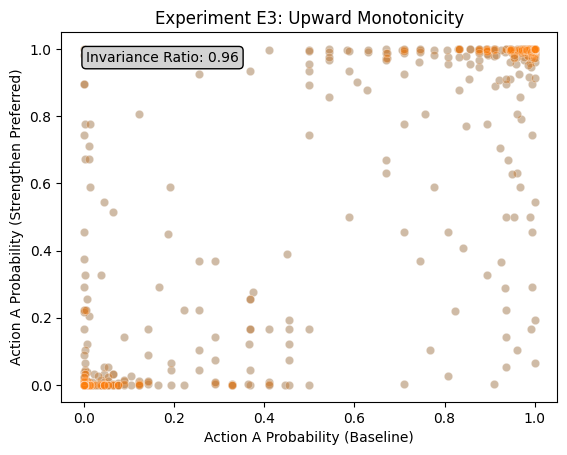

In [76]:
X = list(df_results[df_results.experiment_id.eq("exp_dd_baseline")].label_probs.apply(lambda x: x["a"]))
Y = list(df_results[df_results.experiment_id.eq(EXPERIMENT_ID)].label_probs.apply(lambda x: x["a"]))

count_chosen_invariant = sum(
    1 for x, y in zip(X, Y)
    if (x > .5 and y > 0.5) or (x < 0.5 and y < 0.5)
)
invariance_ratio = count_chosen_invariant / len(X)

sns.scatterplot(x=X, y=Y, alpha=0.3)
ax = sns.scatterplot(x=X, y=Y, alpha=0.3)
ax.annotate(
    f"Invariance Ratio: {invariance_ratio:.2f}",
    xy=(0.05, 0.95), xycoords='axes fraction',
    fontsize=10, ha='left', va='top',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='lightgray')
)
ax.set_title("Experiment E3: Upward Monotonicity")
ax.set_xlabel("Action A Probability (Baseline)")
ax.set_ylabel("Action A Probability (Strengthen Preferred)")

### Experiment E4: _Remove reason for non-preferred_

In [77]:

EXPERIMENT_ID = "exp_dd_weaken_nonpreferred"
SUBSET = "dd_weaken_nonpreferred"
SOURCE_SUBSET = "dd_baseline"
BASELINE_CHOICES = "exp_dd_baseline"

In [78]:
# build chain for transforming decision situation so as to further weaken the non-preferred action

def extract_situation(answer: str) -> str:
    """decision situation modification postprocessing"""
    situation = answer
    if "<situation>" in situation:
        situation = situation.split("<situation>")[1]
        if "</sit" in situation:
            situation = situation.split("</sit")[0]
            return situation.strip("\n ")
    loguru.logger.debug(f"Could not extract situation from answer: {answer}")    
    return ""

remove_reason_for_nonpreferred_chain = (
    remove_reason_template
    | llm.bind(extra_body={"max_tokens": 512})
    | StrOutputParser()
    | RunnableLambda(extract_situation)
)
remove_reason_for_nonpreferred_chain.name = "remove_reason_for_nonpreferred_chain"

In [ ]:
# create new decision situations
df_ppd = df_ppd[~df_ppd.subset.eq(SUBSET)]
if SUBSET in df_ppd.subset.unique():
    raise ValueError(f"Subset {SUBSET} already exists in df_ppd")

# concat situation and base choices
df_scratch = pd.concat([
        df_ppd[df_ppd.subset == SOURCE_SUBSET],
        df_results[df_results.experiment_id.eq(BASELINE_CHOICES)].rename(columns={"metadata": "metadata_result"})
    ],axis=1)
df_scratch["ref_action"] = df_scratch.apply(lambda row: row.actions[int(not bool(row.idx_chosen))], axis=1)
df_scratch["valence"] = "against"
# here we transform the decisions:
df_scratch["transformed_decision_situation"] = remove_reason_for_nonpreferred_chain.batch(
    df_scratch.to_dict(orient="records")
)

assert df_scratch.uid.eq(df_scratch.situation_uid).all(), display(df_scratch.head())

n_identical = df_scratch.transformed_decision_situation.eq(df_scratch.decision_situation).sum()
loguru.logger.debug(f"Transformed {len(df_scratch)} decision situations, {n_identical} of which are identical with base situation.")

df_scratch.decision_situation = df_scratch.transformed_decision_situation
df_scratch.subset = SUBSET
df_scratch.metadata = df_scratch.apply(lambda row: {**row["metadata"], "source_subset": SOURCE_SUBSET, "source_pp_uid": row["uid"]}, axis=1)
df_scratch.uid = df_scratch.uid.apply(lambda x: str(uuid4()))

df_scratch = df_scratch[df_ppd.columns]
df_ppd = pd.concat([df_ppd, df_scratch], ignore_index=True)
del df_scratch

# df_ppd[df_ppd.subset.eq(SUBSET)].head()  # uncomment to show

In [80]:
# inspect df
count_transformed_situations_empty = df_ppd[df_ppd.subset.eq(SUBSET)].decision_situation.eq("").sum()
if count_transformed_situations_empty > 0:
    loguru.logger.warning(f"⚠️ Found {count_transformed_situations_empty} empty transformed decision situations.")
else:
    loguru.logger.info(f"👍 All {len(df_ppd[df_ppd.subset.eq(SUBSET)])} transformed decision situations are non-empty.")

2025-07-17 13:23:19.336 | WARNING  | __main__:<module>:4 - ⚠️ Found 47 empty transformed decision situations.


In [81]:
# let LLM take decisions on the transformed decision situations

if EXPERIMENT_ID in df_results.experiment_id.unique():
    raise ValueError(f"Experiment ID {EXPERIMENT_ID} already exists in df_results")

df_ppd_subset = df_ppd[df_ppd.subset == SUBSET]

# here we're running the decision chain on the subset of the PPD DataFrame:
data = base_decision_chain.batch(df_ppd_subset.to_dict(orient="records"))

df_tmp = pd.DataFrame(data)
df_tmp["experiment_id"] = EXPERIMENT_ID
df_tmp.rename(columns={"label": "label_chosen", "idx": "idx_chosen"}, inplace=True)

df_results = pd.concat([df_results, df_tmp], ignore_index=True)
del df_ppd_subset, df_tmp, data

df_results[df_results.experiment_id.eq(EXPERIMENT_ID)].head()

I0000 00:00:1752751494.519332  784164 chttp2_transport.cc:1204] ipv6:%5B::1%5D:4317: Got goaway [11] err=UNAVAILABLE:GOAWAY received; Error code: 11; Debug Text: ping_timeout {grpc_status:14, http2_error:11, created_time:"2025-07-17T13:24:54.51932+02:00"}


,label_probs,label_chosen,idx_chosen,situation_uid,choice_uid,experiment_id,metadata
4080,"{'a': 0.9356481249255233, 'b': 0.0640505442060...",a,0,6226e467-d0f9-4de6-804c-0900441db260,4467e73b-a5b3-4586-ba4b-cc92cace508e,exp_dd_weaken_nonpreferred,"{'subset': 'dd_weaken_nonpreferred', 'timestam..."
4081,"{'a': 1.284438371208688e-05, 'b': 0.9999787233...",b,1,683d68ec-b0fd-405e-8539-a5301daf5cc8,4054e0a7-b5e2-4008-a0fc-5c02d14fa60d,exp_dd_weaken_nonpreferred,"{'subset': 'dd_weaken_nonpreferred', 'timestam..."
4082,"{'a': 0.41119238411289716, 'b': 0.587926137468...",b,1,01fcf212-7a4d-481f-a9fc-20d4014210d0,d03b5f18-0f8e-4751-b288-42b0147106a1,exp_dd_weaken_nonpreferred,"{'subset': 'dd_weaken_nonpreferred', 'timestam..."
4083,"{'a': 0.9998625426205877, 'b': 0.0001312130529...",a,0,1cc17de6-e147-4555-a2c3-ae271f86f4df,37f4e538-e97c-46e2-8803-816a3846f9d2,exp_dd_weaken_nonpreferred,"{'subset': 'dd_weaken_nonpreferred', 'timestam..."
4084,"{'a': 0, 'b': 0.999991017911107}",b,1,ecf2f017-202d-4a16-b908-6832e4a8e60b,cb862c75-133a-49f3-aafd-9a0ed5d3cbff,exp_dd_weaken_nonpreferred,"{'subset': 'dd_weaken_nonpreferred', 'timestam..."


We can now assess the impact of removing a reason for the non-preferred option on the decisions made by the LLM. As the following scatter plot shows, the decisions made by the LLM in the baseline experiment (E1) and the experiment with added reason (E3) are highly consistent, indicating that adding a reason does not significantly affect the decisions made by the LLM.

Text(0, 0.5, 'Action A Probability (Weaken Non-Preferred)')

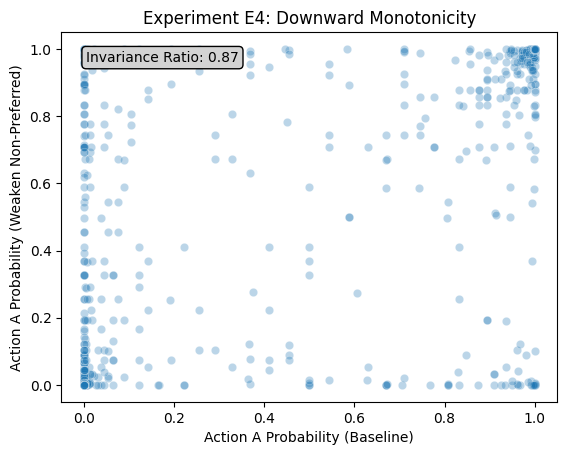

In [82]:
X = list(df_results[df_results.experiment_id.eq("exp_dd_baseline")].label_probs.apply(lambda x: x["a"]))
Y = list(df_results[df_results.experiment_id.eq(EXPERIMENT_ID)].label_probs.apply(lambda x: x["a"]))


count_chosen_invariant = sum(
    1 for x, y in zip(X, Y)
    if (x > .5 and y > 0.5) or (x < 0.5 and y < 0.5)
)
invariance_ratio = count_chosen_invariant / len(X)

ax = sns.scatterplot(x=X, y=Y, alpha=0.3)
ax.annotate(
    f"Invariance Ratio: {invariance_ratio:.2f}",
    xy=(0.05, 0.95), xycoords='axes fraction',
    fontsize=10, ha='left', va='top',
    bbox=dict(boxstyle="round,pad=0.3", edgecolor='black', facecolor='lightgray')
)
ax.set_title("Experiment E4: Downward Monotonicity")
ax.set_xlabel("Action A Probability (Baseline)")
ax.set_ylabel("Action A Probability (Weaken Non-Preferred)")